In [ ]:
# Install if needed
!pip install xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('heart.csv')  # Make sure 'heart.csv' is uploaded to your Colab environment or provide the correct path.

# Features & target
X = df.drop('target', axis=1)
y = df['target']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling (important for some models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import os

# List all files and directories in the current working directory
print(os.listdir('.'))


['.config', 'sample_data']


In [ ]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))

Accuracy: 0.8032786885245902
Precision: 0.7692307692307693
Recall: 0.9090909090909091


Logistic Regression

In [ ]:
from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()
model_nb.fit(X_train_scaled, y_train)

y_pred_nb = model_nb.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))

Accuracy: 0.819672131147541
Precision: 0.7894736842105263
Recall: 0.9090909090909091


Naive Bayes

In [ ]:
from sklearn.svm import SVC

model_svm = SVC(kernel='rbf', probability=True)
model_svm.fit(X_train_scaled, y_train)

y_pred_svm = model_svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))

Accuracy: 0.819672131147541
Precision: 0.775
Recall: 0.9393939393939394


SVM

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)

y_pred_knn = model_knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))

Accuracy: 0.8032786885245902
Precision: 0.7692307692307693
Recall: 0.9090909090909091


KNN

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))

Accuracy: 0.7868852459016393
Precision: 0.75
Recall: 0.9090909090909091


Decision Tree

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))

Accuracy: 0.8360655737704918
Precision: 0.7804878048780488
Recall: 0.9696969696969697


Random forest

<Axes: >

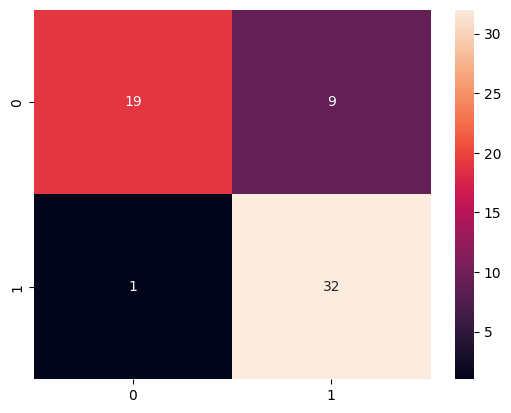

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')

Confusion Matrix Visualization

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.68      0.79        28
           1       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61



Classification Report

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model_rf, X, y, cv=5)
print("Average CV Accuracy:", scores.mean())

Average CV Accuracy: 0.8314207650273223


Cross Validation


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Load dataset (if not already loaded)
df = pd.read_csv('heart.csv')

# Features & target (if not already defined)
X = df.drop('target', axis=1)
y = df['target']

# Train-Test Split (if not already performed)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss')

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:59:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7704918032786885
Precision: 0.7567567567567568
Recall: 0.8484848484848485


XG Boost

In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Scaling (if not already performed or if kernel was reset)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_nn = MLPClassifier(hidden_layer_sizes=(64,32),
                         max_iter=1000,
                         random_state=42)

model_nn.fit(X_train_scaled, y_train)

y_pred_nn = model_nn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("Precision:", precision_score(y_test, y_pred_nn))
print("Recall:", recall_score(y_test, y_pred_nn))

Accuracy: 0.7868852459016393
Precision: 0.7941176470588235
Recall: 0.8181818181818182


Nerual Network